# Validation against observed snow depth

This notebook compares all three model products against measured snow depth from MET observations:

- FSM2
- seNorge
- SNOWPACK

The analysis is separate from the SNOWPACK-as-reference comparison. Here, the reference is the actual observation series from `data/snowdepth.csv`.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Transformer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED = DATA_DIR / "processed"

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

PROJECT_ROOT

PosixPath('/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models')

## Helper functions

In [2]:
def load_observations(path):
    obs = pd.read_csv(path, sep=";", header=None, skiprows=1, names=["station_name", "station_id", "time", "snow_depth_cm"])
    obs = obs.dropna(subset=["station_id", "time", "snow_depth_cm"]).copy()
    obs["time"] = pd.to_datetime(obs["time"], format="%d.%m.%Y", errors="coerce")
    obs["snow_depth_cm"] = pd.to_numeric(obs["snow_depth_cm"], errors="coerce")
    obs = obs.dropna(subset=["time", "snow_depth_cm"])
    obs = obs[obs["snow_depth_cm"] != -9999].copy()
    obs["snow_depth"] = obs["snow_depth_cm"] / 100.0
    obs["station_id"] = obs["station_id"].astype(str).str.strip()
    obs["station_name"] = obs["station_name"].astype(str).str.strip()
    return obs[["station_name", "station_id", "time", "snow_depth"]]


def load_station_metadata(path):
    meta = pd.read_csv(path)
    meta = meta[["Station", "Station_Code", "lat", "lon"]].drop_duplicates().copy()
    meta = meta.rename(columns={"Station": "station_name", "Station_Code": "station_id"})
    meta["station_id"] = meta["station_id"].astype(str).str.strip()

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32633", always_xy=True)
    x, y = transformer.transform(meta["lon"].to_numpy(), meta["lat"].to_numpy())
    meta["x_utm33"] = x
    meta["y_utm33"] = y
    return meta


def calculate_metrics(model, obs):
    model_arr = np.asarray(model, dtype=float)
    obs_arr = np.asarray(obs, dtype=float)
    valid = np.isfinite(model_arr) & np.isfinite(obs_arr)
    n = int(valid.sum())
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    model_clean = model_arr[valid]
    obs_clean = obs_arr[valid]
    diff = model_clean - obs_clean
    bias = float(diff.mean())
    rmse = float(np.sqrt((diff**2).mean()))
    corr = float(np.corrcoef(model_clean, obs_clean)[0, 1]) if n > 1 else np.nan
    return bias, rmse, corr, n


def observation_series(obs, station_id):
    df = obs[obs["station_id"] == station_id].copy()
    df = df.groupby("time", as_index=True)["snow_depth"].mean().sort_index()
    return xr.DataArray(df, coords={"time": df.index}, dims="time", name="OBS")


def nearest_snowpack_station(snowpack_ds, x0, y0):
    distances = np.sqrt((snowpack_ds["x"].values - x0) ** 2 + (snowpack_ds["y"].values - y0) ** 2)
    idx = int(np.nanargmin(distances))
    return idx, str(snowpack_ds["station"].values[idx]), float(distances[idx])


def aligned_model_series(obs_ts, fsm_sd, senorge_sd, snowpack_sd_daily, snowpack_ds, x0, y0):
    fsm_ts = fsm_sd.sel(x=x0, y=y0, method="nearest")
    senorge_ts = senorge_sd.sel(x=x0, y=y0, method="nearest")
    sp_idx, sp_station, sp_distance = nearest_snowpack_station(snowpack_ds, x0, y0)
    snowpack_ts = snowpack_sd_daily.isel(station=sp_idx)

    obs_aligned, fsm_aligned, senorge_aligned, snowpack_aligned = xr.align(
        obs_ts, fsm_ts, senorge_ts, snowpack_ts, join="inner"
    )

    match_info = {
        "FSM2_x": float(fsm_aligned["x"].values),
        "FSM2_y": float(fsm_aligned["y"].values),
        "seNorge_x": float(senorge_aligned["x"].values),
        "seNorge_y": float(senorge_aligned["y"].values),
        "SNOWPACK_Station": sp_station,
        "SNOWPACK_Distance_m": sp_distance,
    }
    return obs_aligned, fsm_aligned, senorge_aligned, snowpack_aligned, match_info

## Load observations and station metadata

The station metadata are read from the existing coordinate table, but the coordinates are converted from latitude/longitude to UTM zone 33 before matching against the model grids.

In [ ]:
obs = load_observations(DATA_DIR / "snowdepth.csv")
station_meta = load_station_metadata(PROCESSED / "validation_stations_with_coordinates.csv")

obs_stations = obs[["station_name", "station_id"]].drop_duplicates().sort_values("station_id")
station_meta = obs_stations.merge(station_meta, on=["station_name", "station_id"], how="left")

print("Observation records:", len(obs))
print("Observation period:", obs["time"].min().date(), "to", obs["time"].max().date())
print("Stations:", len(obs_stations))
station_meta

Observation records: 2742
Observation period: 2024-09-01 to 2025-05-31
Stations: 11


,station_name,station_id,lat,lon,x_utm33,y_utm33
0,Øvre Heimdalsvatn,SN13750,60.9536,8.3536,140427.405303,6.775882e+06
1,Fv51 Valdresflye,SN13760,61.1331,8.8225,167628.467116,6.793327e+06
2,Juvvasshøe,SN15270,61.8903,7.1922,90287.517125,6.886638e+06
3,Bøverdal,SN15430,61.0975,8.0681,126719.174335,6.793451e+06
4,Skjåk,SN15660,61.0753,8.0275,124274.980706,6.791221e+06
5,Grotli Iii,SN15890,61.3706,8.2233,138212.306107,6.822879e+06
6,Beitostølen Ii,SN23550,60.8806,8.6640,156396.399891,6.766110e+06
7,Filefjell - Kyrkjestølane,SN54710,60.9947,8.8364,166922.331637,6.777888e+06
8,Fv53 Tyinosen,SN54815,61.1056,8.7856,165356.142836,6.790461e+06
9,Sognefjellhytta,SN55290,61.5064,8.0233,129182.511030,6.839072e+06


: 

## Load model data

In [ ]:
fsm_ds = xr.open_dataset(PROCESSED / "fsm2_sd_all.nc")
senorge_ds = xr.open_dataset(PROCESSED / "senorge_all.nc")
snowpack_ds = xr.open_dataset(PROCESSED / "snowpack_all.nc")

fsm_sd = fsm_ds["snow_depth"] / 1000.0
senorge_sd = senorge_ds["snow_depth"] / 100.0
snowpack_sd = snowpack_ds["HS_mod"] / 100.0
snowpack_sd_daily = snowpack_sd.resample(time="1D").mean()

fsm_sd.attrs["units"] = "m"
senorge_sd.attrs["units"] = "m"
snowpack_sd_daily.attrs["units"] = "m"

print("FSM2:", fsm_sd.shape, str(fsm_sd.time.values[0]), "to", str(fsm_sd.time.values[-1]))
print("seNorge:", senorge_sd.shape, str(senorge_sd.time.values[0]), "to", str(senorge_sd.time.values[-1]))
print("SNOWPACK daily:", snowpack_sd_daily.shape, str(snowpack_sd_daily.time.values[0]), "to", str(snowpack_sd_daily.time.values[-1]))

## Validate all three models against observations

In [ ]:
results = []
time_series = []

for _, station in station_meta.iterrows():
    station_name = station["station_name"]
    station_id = station["station_id"]
    x0 = station["x_utm33"]
    y0 = station["y_utm33"]

    if pd.isna(x0) or pd.isna(y0):
        print(f"Skipping {station_name}: missing coordinates")
        continue

    obs_ts = observation_series(obs, station_id)
    obs_aligned, fsm_ts, senorge_ts, snowpack_ts, match_info = aligned_model_series(
        obs_ts, fsm_sd, senorge_sd, snowpack_sd_daily, snowpack_ds, x0, y0
    )

    station_result = {
        "Station": station_name,
        "Station_Code": station_id,
        "lat": station["lat"],
        "lon": station["lon"],
        "x_utm33": x0,
        "y_utm33": y0,
        "Period_Start": pd.to_datetime(obs_aligned.time.values[0]).date() if len(obs_aligned.time) else pd.NaT,
        "Period_End": pd.to_datetime(obs_aligned.time.values[-1]).date() if len(obs_aligned.time) else pd.NaT,
        **match_info,
    }

    for model_name, model_ts in [("FSM2", fsm_ts), ("seNorge", senorge_ts), ("SNOWPACK", snowpack_ts)]:
        bias, rmse, corr, n = calculate_metrics(model_ts.values, obs_aligned.values)
        station_result[f"{model_name}_Bias"] = bias
        station_result[f"{model_name}_RMSE"] = rmse
        station_result[f"{model_name}_Corr"] = corr
        station_result[f"{model_name}_N"] = n

    station_result["N_Days"] = min(station_result["FSM2_N"], station_result["seNorge_N"], station_result["SNOWPACK_N"])
    rmse_cols = ["FSM2_RMSE", "seNorge_RMSE", "SNOWPACK_RMSE"]
    station_result["best_model_rmse"] = min(rmse_cols, key=lambda c: station_result[c]).replace("_RMSE", "")
    station_result["worst_model_rmse"] = max(rmse_cols, key=lambda c: station_result[c]).replace("_RMSE", "")
    results.append(station_result)

    ts_df = pd.DataFrame({
        "time": pd.to_datetime(obs_aligned.time.values),
        "Station": station_name,
        "OBS": obs_aligned.values,
        "FSM2": fsm_ts.values,
        "seNorge": senorge_ts.values,
        "SNOWPACK": snowpack_ts.values,
    })
    time_series.append(ts_df)

results_df = pd.DataFrame(results)
time_series_df = pd.concat(time_series, ignore_index=True)

results_df

,Station,Station_Code,lat,lon,x_utm33,y_utm33,Period_Start,Period_End,FSM2_x,FSM2_y,seNorge_x,seNorge_y,SNOWPACK_Station,SNOWPACK_Distance_m,FSM2_Bias,FSM2_RMSE,FSM2_Corr,FSM2_N,seNorge_Bias,seNorge_RMSE,seNorge_Corr,seNorge_N,SNOWPACK_Bias,SNOWPACK_RMSE,SNOWPACK_Corr,SNOWPACK_N,N_Days,best_model_rmse,worst_model_rmse
0,Øvre Heimdalsvatn,SN13750,60.9536,8.3536,140427.405303,6.775882e+06,2024-09-01,2025-05-31,140000.0,6776000.0,140000.0,6776000.0,VIR3243A,9688.586329,-0.001767,0.202290,0.832219,249,-0.150574,0.234038,0.837661,249,0.578887,0.742371,0.670797,249,249,FSM2,SNOWPACK
1,Fv51 Valdresflye,SN13760,61.1331,8.8225,167628.467116,6.793327e+06,2024-09-01,2025-05-31,168000.0,6793000.0,168000.0,6793000.0,VIR4720A,5637.929232,-0.398075,0.593570,0.463714,213,-0.404239,0.598346,0.464696,213,-0.407968,0.601916,0.457993,213,213,FSM2,SNOWPACK
2,Juvvasshøe,SN15270,61.8903,7.1922,90287.517125,6.886638e+06,2024-10-18,2025-05-31,90000.0,6887000.0,90000.0,6887000.0,VIR8A,11718.072201,-0.359115,0.488907,0.019359,226,-0.349226,0.521931,-0.241051,226,2.293094,2.490752,0.934284,226,226,FSM2,SNOWPACK
3,Bøverdal,SN15430,61.0975,8.0681,126719.174335,6.793451e+06,2024-09-01,2025-05-31,127000.0,6793000.0,127000.0,6793000.0,VIR1635A,4154.695082,0.688496,0.876578,0.329302,266,0.277447,0.386686,0.427582,266,0.613823,0.790029,0.199029,266,266,seNorge,FSM2
4,Skjåk,SN15660,61.0753,8.0275,124274.980706,6.791221e+06,2024-09-01,2025-05-31,124000.0,6791000.0,124000.0,6791000.0,VIR1635A,7457.688509,0.723022,0.933699,0.325247,268,0.424030,0.560551,0.201566,268,0.624855,0.804264,0.123952,268,268,seNorge,FSM2
5,Grotli Iii,SN15890,61.3706,8.2233,138212.306107,6.822879e+06,2024-09-01,2025-05-31,138000.0,6823000.0,138000.0,6823000.0,VIR2420A,244.296784,0.922601,1.133249,0.881036,273,0.624396,0.799574,0.738898,273,0.776494,1.003969,0.806386,273,273,seNorge,FSM2
6,Beitostølen Ii,SN23550,60.8806,8.6640,156396.399891,6.766110e+06,2024-09-01,2025-05-31,156000.0,6766000.0,156000.0,6766000.0,VIR4120A,7899.528792,0.166996,0.246073,0.967186,273,0.225066,0.317978,0.685305,273,-0.080308,0.150896,0.720757,273,273,SNOWPACK,seNorge
7,Filefjell - Kyrkjestølane,SN54710,60.9947,8.8364,166922.331637,6.777888e+06,2024-09-01,2025-05-31,167000.0,6778000.0,167000.0,6778000.0,VIR4714A,5823.733764,0.049084,0.200258,0.674854,273,0.010769,0.116564,0.831606,273,0.074432,0.194859,0.776315,273,273,seNorge,FSM2
8,Fv53 Tyinosen,SN54815,61.1056,8.7856,165356.142836,6.790461e+06,2024-11-01,2025-05-31,165000.0,6790000.0,165000.0,6790000.0,VIR4717A,3387.707962,-0.106632,0.323741,0.327254,190,-0.131426,0.282366,0.535762,190,-0.052977,0.238844,0.637417,190,190,SNOWPACK,FSM2
9,Sognefjellhytta,SN55290,61.5064,8.0233,129182.511030,6.839072e+06,2024-10-03,2025-05-31,129000.0,6839000.0,129000.0,6839000.0,VIR1584A,196.294904,-0.237866,0.549242,0.705611,239,-0.018297,0.168725,0.967766,239,-0.353771,0.501311,0.836234,239,239,seNorge,FSM2


## Summary statistics

In [ ]:
summary_rows = []
for model in ["FSM2", "seNorge", "SNOWPACK"]:
    summary_rows.append({
        "Model": model,
        "Mean Bias": results_df[f"{model}_Bias"].mean(),
        "Median Bias": results_df[f"{model}_Bias"].median(),
        "Mean Abs Bias": results_df[f"{model}_Bias"].abs().mean(),
        "Mean RMSE": results_df[f"{model}_RMSE"].mean(),
        "Median RMSE": results_df[f"{model}_RMSE"].median(),
        "Mean Corr": results_df[f"{model}_Corr"].mean(),
        "Median Corr": results_df[f"{model}_Corr"].median(),
    })

summary_df = pd.DataFrame(summary_rows)
print("Best model by RMSE:")
display(results_df["best_model_rmse"].value_counts())
summary_df.round(3)

Best model by RMSE:


best_model_rmse
seNorge     5
FSM2        4
SNOWPACK    2
Name: count, dtype: int64

,Model,Mean Bias,Median Bias,Mean Abs Bias,Mean RMSE,Median RMSE,Mean Corr,Median Corr
0,FSM2,0.141,0.049,0.342,0.524,0.489,0.552,0.552
1,seNorge,0.064,0.011,0.255,0.390,0.318,0.540,0.536
2,SNOWPACK,0.405,0.393,0.568,0.733,0.602,0.586,0.671


## Check station matching distances

Large SNOWPACK distances mean the nearest virtual station is not very close to the observation station. Those cases should be treated carefully in the interpretation.

In [ ]:
match_cols = ["Station", "Station_Code", "lat", "lon", "x_utm33", "y_utm33", "SNOWPACK_Station", "SNOWPACK_Distance_m"]
results_df[match_cols].sort_values("SNOWPACK_Distance_m", ascending=False).round(0)

,Station,Station_Code,lat,lon,x_utm33,y_utm33,SNOWPACK_Station,SNOWPACK_Distance_m
10,Skjolden,SN55300,61.0,8.0,102565.0,6792052.0,VIR1378A,26776.0
2,Juvvasshøe,SN15270,62.0,7.0,90288.0,6886638.0,VIR8A,11718.0
0,Øvre Heimdalsvatn,SN13750,61.0,8.0,140427.0,6775882.0,VIR3243A,9689.0
6,Beitostølen Ii,SN23550,61.0,9.0,156396.0,6766110.0,VIR4120A,7900.0
4,Skjåk,SN15660,61.0,8.0,124275.0,6791221.0,VIR1635A,7458.0
7,Filefjell - Kyrkjestølane,SN54710,61.0,9.0,166922.0,6777888.0,VIR4714A,5824.0
1,Fv51 Valdresflye,SN13760,61.0,9.0,167628.0,6793327.0,VIR4720A,5638.0
3,Bøverdal,SN15430,61.0,8.0,126719.0,6793451.0,VIR1635A,4155.0
8,Fv53 Tyinosen,SN54815,61.0,9.0,165356.0,6790461.0,VIR4717A,3388.0
5,Grotli Iii,SN15890,61.0,8.0,138212.0,6822879.0,VIR2420A,244.0


## Save results

In [ ]:
results_path = PROCESSED / "observation_validation_three_models.csv"
summary_path = PROCESSED / "observation_validation_summary.csv"
time_series_path = PROCESSED / "observation_validation_timeseries.csv"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)
time_series_df.to_csv(time_series_path, index=False)

print(results_path)
print(summary_path)
print(time_series_path)

/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/data/processed/observation_validation_three_models.csv
/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/data/processed/observation_validation_summary.csv
/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/data/processed/observation_validation_timeseries.csv


## Figure 12: Metrics by observation station

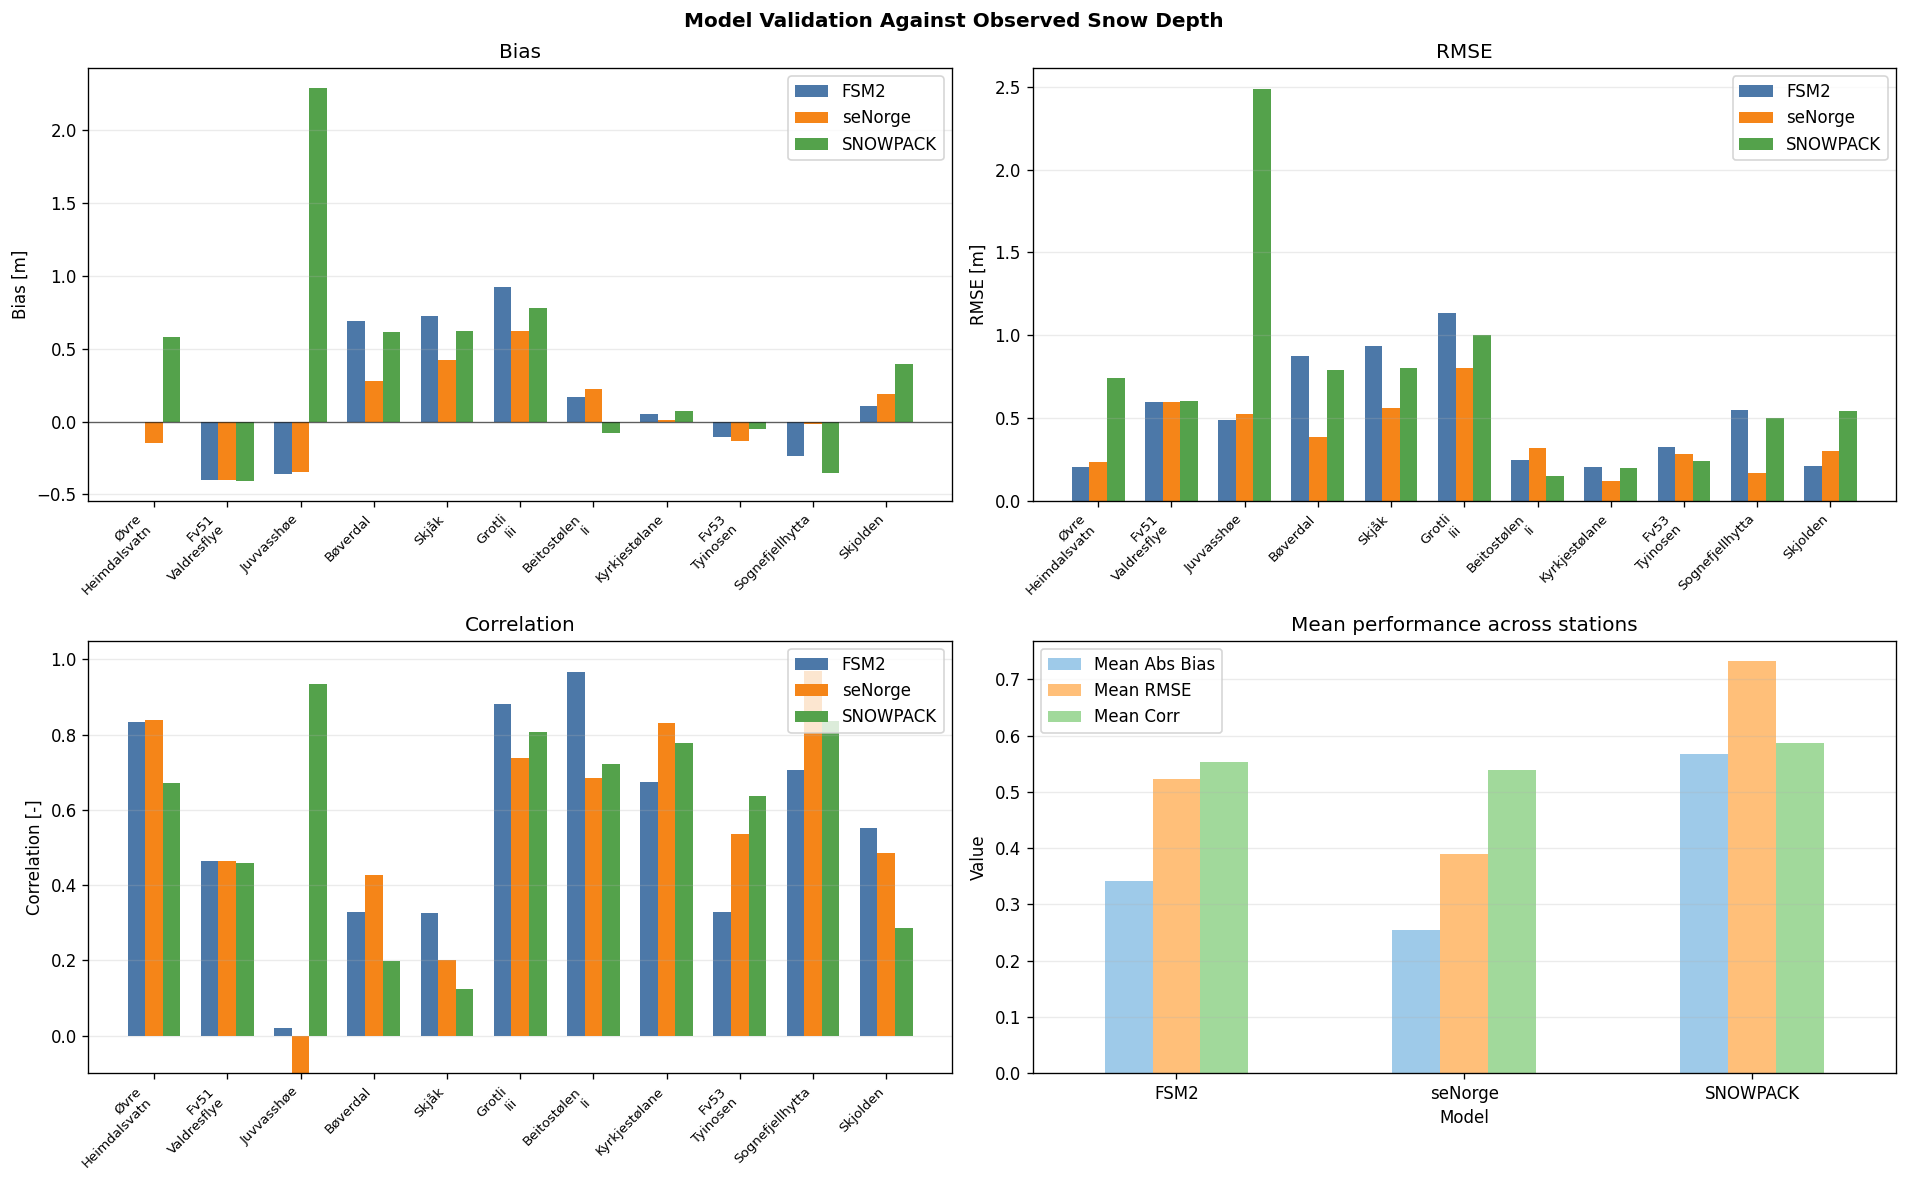

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
models = ["FSM2", "seNorge", "SNOWPACK"]
colors = ["#4c78a8", "#f58518", "#54a24b"]
x = np.arange(len(results_df))
width = 0.24
labels = results_df["Station"].str.replace("Filefjell - ", "", regex=False).str.replace(" ", "\n", regex=False)

for offset, model, color in zip([-width, 0, width], models, colors):
    axes[0, 0].bar(x + offset, results_df[f"{model}_Bias"], width, label=model, color=color)
axes[0, 0].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[0, 0].set_title("Bias")
axes[0, 0].set_ylabel("Bias [m]")

for offset, model, color in zip([-width, 0, width], models, colors):
    axes[0, 1].bar(x + offset, results_df[f"{model}_RMSE"], width, label=model, color=color)
axes[0, 1].set_title("RMSE")
axes[0, 1].set_ylabel("RMSE [m]")

for offset, model, color in zip([-width, 0, width], models, colors):
    axes[1, 0].bar(x + offset, results_df[f"{model}_Corr"], width, label=model, color=color)
axes[1, 0].set_title("Correlation")
axes[1, 0].set_ylabel("Correlation [-]")
axes[1, 0].set_ylim(-0.1, 1.05)

summary_plot = summary_df.set_index("Model")[["Mean Abs Bias", "Mean RMSE", "Mean Corr"]]
summary_plot.plot(kind="bar", ax=axes[1, 1], color=["#9ecae9", "#ffbf79", "#a1d99b"])
axes[1, 1].set_title("Mean performance across stations")
axes[1, 1].set_ylabel("Value")
axes[1, 1].tick_params(axis="x", rotation=0)

for ax in axes.ravel()[:3]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()

axes[1, 1].grid(True, axis="y", alpha=0.25)
fig.suptitle("Model Validation Against Observed Snow Depth", fontweight="bold")
fig.tight_layout()
fig.savefig(PROCESSED / "Figure_12_Observation_Validation_Three_Models.png", bbox_inches="tight")
plt.show()

## Figure 13: Example time series

The examples are selected automatically: one station where SNOWPACK has the lowest RMSE, one where FSM2 has the lowest RMSE if present, and the station with the largest SNOWPACK matching distance.

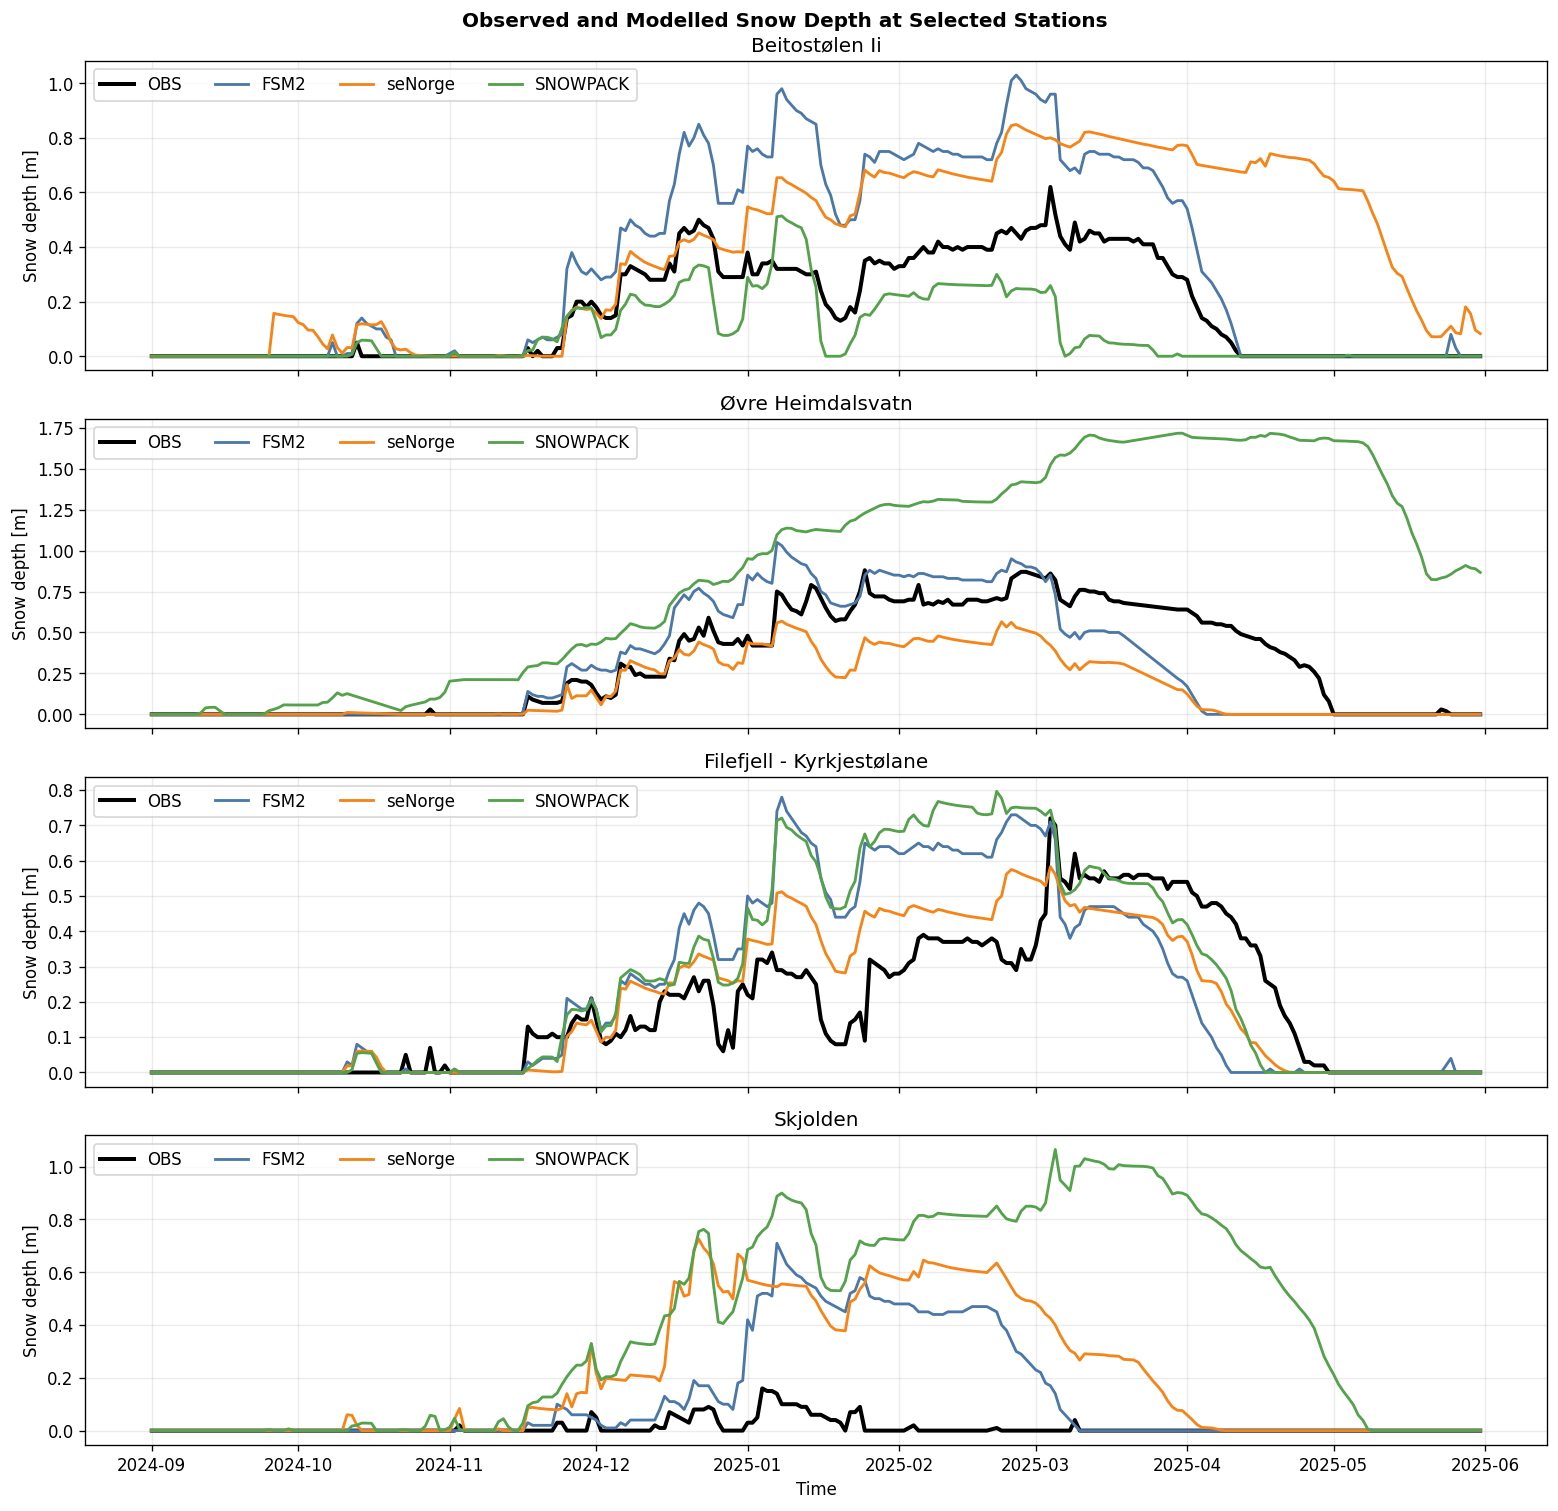

In [ ]:
example_stations = []
for model in ["SNOWPACK", "FSM2", "seNorge"]:
    subset = results_df[results_df["best_model_rmse"] == model]
    if not subset.empty:
        example_stations.append(subset.sort_values(f"{model}_RMSE").iloc[0]["Station"])
example_stations.append(results_df.sort_values("SNOWPACK_Distance_m", ascending=False).iloc[0]["Station"])
example_stations = list(dict.fromkeys(example_stations))[:4]

fig, axes = plt.subplots(len(example_stations), 1, figsize=(13, 3.2 * len(example_stations)), sharex=True)
if len(example_stations) == 1:
    axes = [axes]

for ax, station in zip(axes, example_stations):
    ts = time_series_df[time_series_df["Station"] == station].copy()
    ax.plot(ts["time"], ts["OBS"], label="OBS", color="black", linewidth=2.4)
    ax.plot(ts["time"], ts["FSM2"], label="FSM2", color="#4c78a8", linewidth=1.7)
    ax.plot(ts["time"], ts["seNorge"], label="seNorge", color="#f58518", linewidth=1.7)
    ax.plot(ts["time"], ts["SNOWPACK"], label="SNOWPACK", color="#54a24b", linewidth=1.7)
    ax.set_title(station)
    ax.set_ylabel("Snow depth [m]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=4, loc="upper left")

axes[-1].set_xlabel("Time")
fig.suptitle("Observed and Modelled Snow Depth at Selected Stations", fontweight="bold")
fig.tight_layout()
fig.savefig(PROCESSED / "Figure_13_Observation_Timeseries_Examples.png", bbox_inches="tight")
plt.show()

## Interpretation notes

Use the observation validation as a separate result from the SNOWPACK-reference comparison.

Suggested wording:

- The observation validation compares each model directly against measured snow depth, while the earlier gridded/station-point analysis used SNOWPACK as the reference.
- SNOWPACK is not necessarily located exactly at each observation station. The distance to the nearest SNOWPACK point should therefore be reported and considered when interpreting the results.
- Stations with large SNOWPACK matching distances are less suitable for strong conclusions about local SNOWPACK performance.
- Differences between the observation validation and the SNOWPACK-reference validation may reflect both model performance and representativeness errors caused by comparing point observations with grid cells or nearby virtual stations.